1. ETL (Extract, Transform, Load), Validations
2. EDA (Exploratory Data Analysis)
3. Preprocessing and Feature Engineering
4. Cross-Validation
5. Hyperparameter Tuning
6. Training
7. Evaluation
8. Metrics
9. Inference

In [70]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
print("Libraries imported successfully.")



Libraries imported successfully.


In [9]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables)

X_raw = X.copy()
y_raw = y.copy()

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [10]:
X_raw.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0


In [11]:
df = X_raw.copy()
df['target'] = y_raw.values.ravel()

df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,3
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,2
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1


# Data Quality check

In [16]:
missing_values = df.isnull().sum()
print("Missing values in each column:")
missing_pct = (missing_values / len(df)) * 100
quality_df = pd.DataFrame({
    'missing_values': missing_values,
    'missing_pct': missing_pct
})
print(quality_df[quality_df['missing_values'] > 0])


dupes = df.duplicated().sum()
print(f"Number of duplicate rows: {dupes}")

df.dtypes.value_counts()

Missing values in each column:
      missing_values  missing_pct
ca                 4     1.320132
thal               2     0.660066
Number of duplicate rows: 0


int64      11
float64     3
Name: count, dtype: int64

In [18]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.44,9.04,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.68,0.47,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.16,0.96,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.69,17.60,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.69,51.78,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.15,0.36,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.99,0.99,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.61,22.88,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.33,0.47,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2


In [24]:
df['target_binary'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
(df['target_binary'].value_counts() / len(df) * 100).round(2)

df.head(3)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,target_binary
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1,1


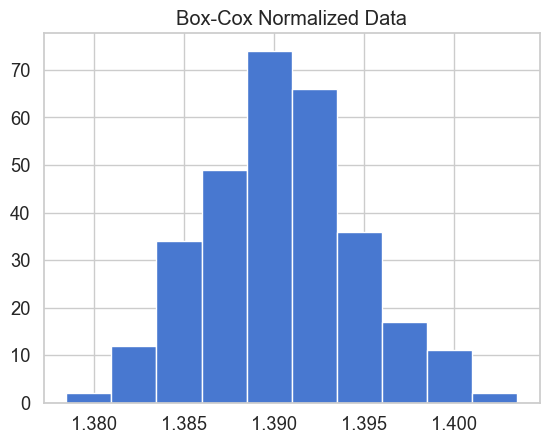

In [31]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Generate right-skewed data
data = df['trestbps']

# Apply Box-Cox transform
normalized_data, lambda_value = stats.boxcox(data)

# Visualize
plt.hist(normalized_data, bins=10)
plt.title("Box-Cox Normalized Data")
plt.show()

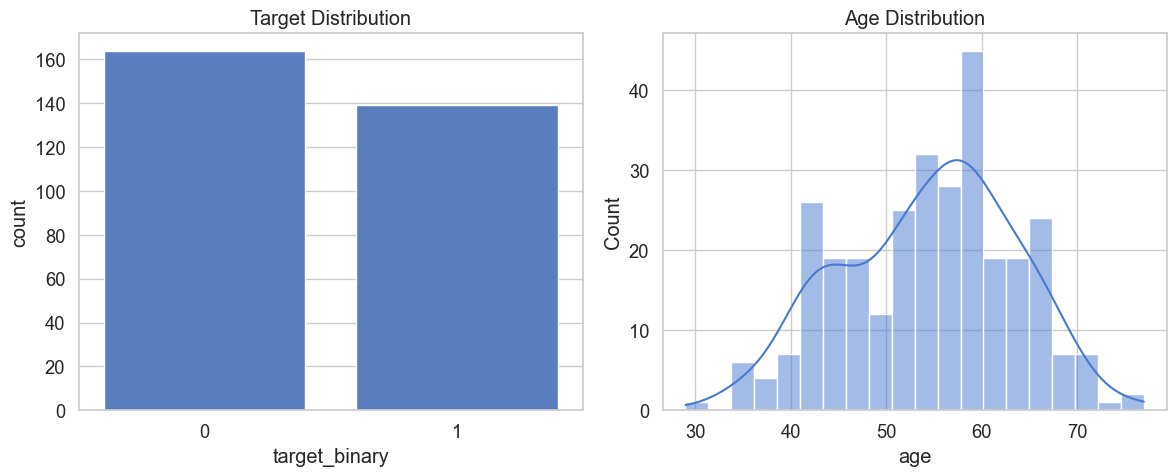

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='target_binary', data=df, ax=axes[0])
axes[0].set_title('Target Distribution')
sns.histplot(df['age'], bins=20, kde=True, ax=axes[1])
axes[1].set_title('Age Distribution')
plt.tight_layout()
plt.show()

In [39]:
# vc5

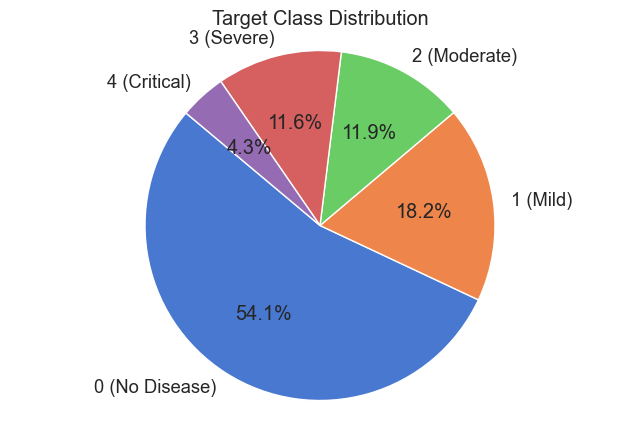

In [38]:
vc5 = df['target'].value_counts().sort_index()
labels = ['0 (No Disease)', '1 (Mild)', '2 (Moderate)', '3 (Severe)', '4 (Critical)']
plt.figure(figsize=(8, 5))
plt.pie(vc5, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Target Class Distribution')
plt.axis('equal')
plt.show() 

# Feature DISTRIBUTION

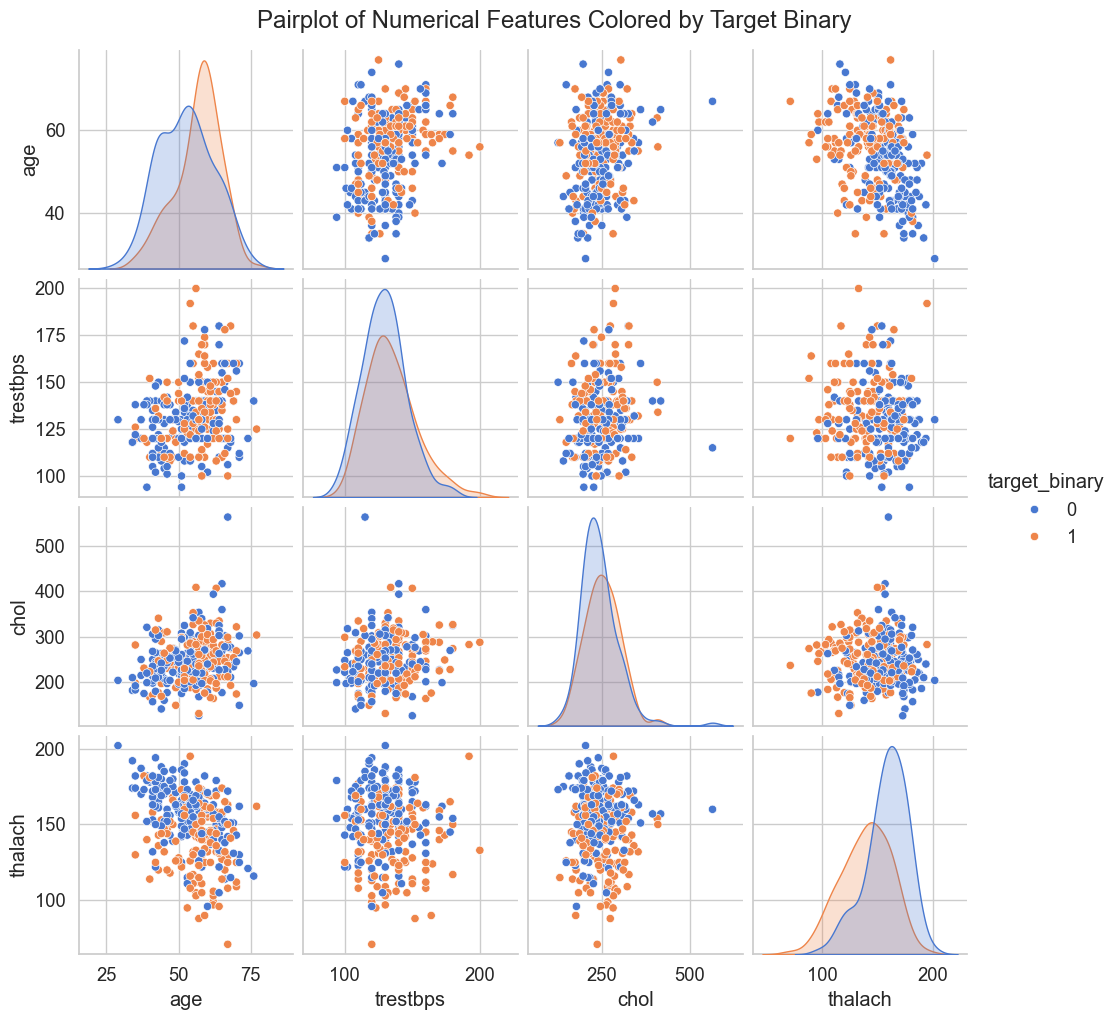

In [40]:
sns.pairplot(df, hue='target_binary', vars=['age', 'trestbps', 'chol', 'thalach'])
plt.suptitle('Pairplot of Numerical Features Colored by Target Binary', y=1.02)
plt.show() 

In [42]:
df.head(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,target_binary
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1,1


Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


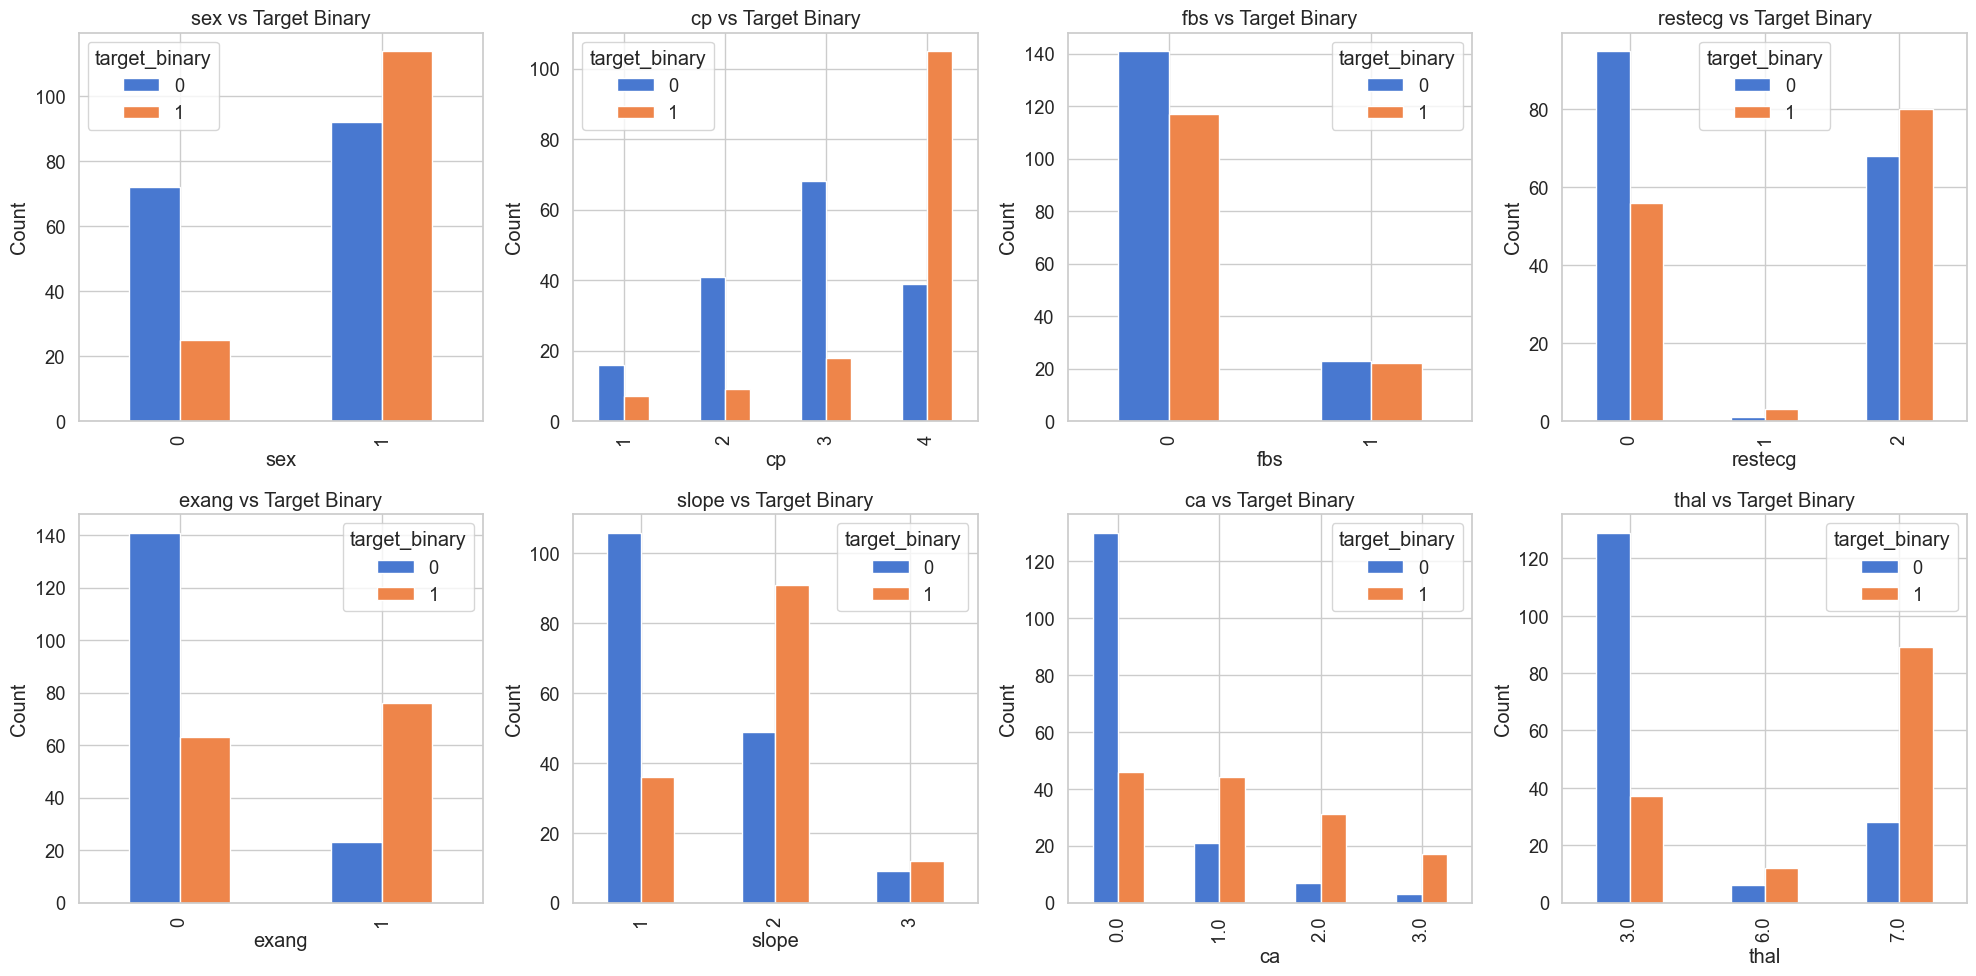

In [49]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
print("Categorical columns:", categorical_cols)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['target_binary'])
    ct.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'{col} vs Target Binary')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.show()

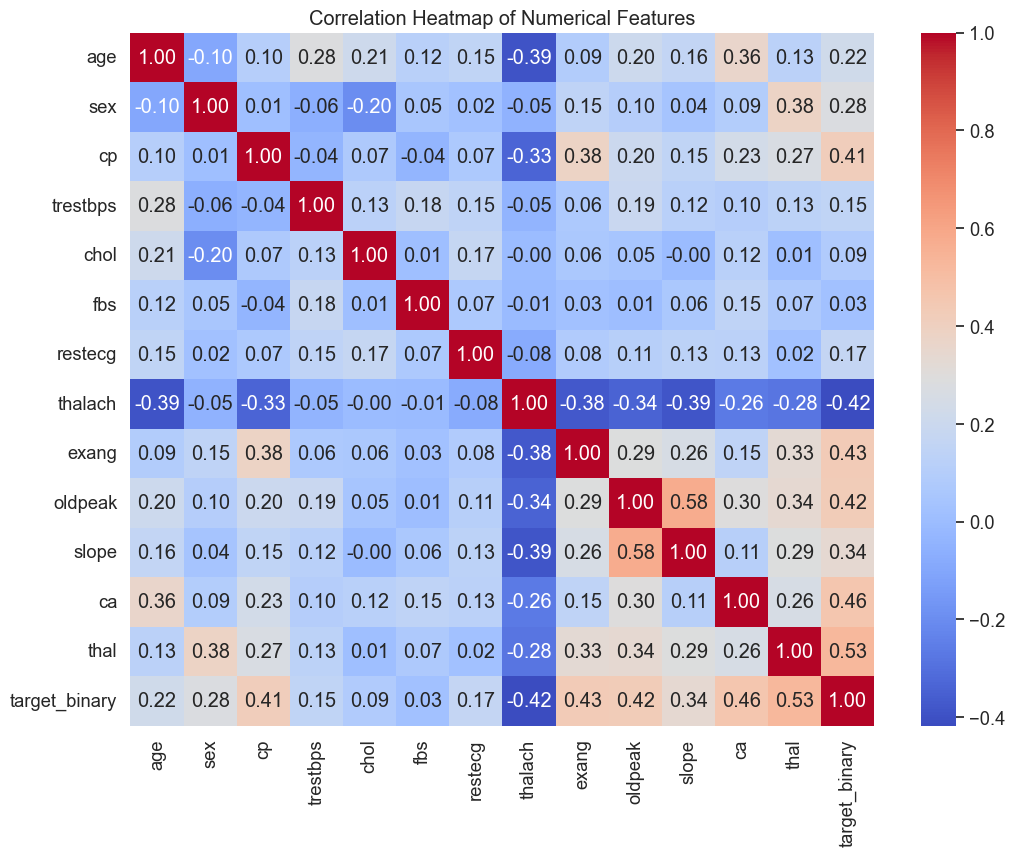

In [50]:
plt.figure(figsize=(12, 9))
corr = df.drop(columns=['target']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

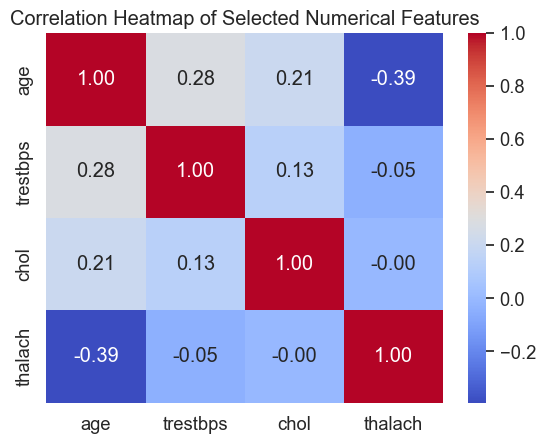

In [53]:
corr = df[['age', 'trestbps', 'chol', 'thalach']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Selected Numerical Features')
plt.show()

In [55]:
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

X = df[numerical_cols + categorical_cols].copy()
y = df['target_binary'].copy()

print(f"total samples: {len(X)}")
print(f"numerical features: {numerical_cols}")
print(f"categorical features: {categorical_cols}")

print("missing percentage in numerical features:")
for col in numerical_cols:
    missing_pct = (X[col].isnull().sum() / len(X)) * 100
    print(f"  {col}: {missing_pct:.2f}%")

print("missing percentage in categorical features:")
for col in categorical_cols:
    missing_pct = (X[col].isnull().sum() / len(X)) * 100
    print(f"  {col}: {missing_pct:.2f}%")

total samples: 303
numerical features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
missing percentage in numerical features:
  age: 0.00%
  trestbps: 0.00%
  chol: 0.00%
  thalach: 0.00%
  oldpeak: 0.00%
missing percentage in categorical features:
  sex: 0.00%
  cp: 0.00%
  fbs: 0.00%
  restecg: 0.00%
  exang: 0.00%
  slope: 0.00%
  ca: 1.32%
  thal: 0.66%


In [56]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"X_train_proc shape: {X_train_proc.shape}")
print(f"X_test_proc shape: {X_test_proc.shape}")


X_train_proc shape: (242, 28)
X_test_proc shape: (61, 28)


In [66]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
# print("Cross-validation strategy defined: StratifiedKFold with 5 splits.")

baseline_model = {
    'Logistic Regression' : Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=SEED, max_iter=1000))
    ]),
    'Decision Tree' : Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=SEED))
    ]),
    'Random Forest' : Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=SEED))
    ]),
    'Gradient Boosting' : Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(random_state=SEED))
    ]),
    'SVM' : Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', SVC(random_state=SEED))
    ]),
    'KNN' : Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier())
    ])
}

cv_results = {}
for name, model in baseline_model.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv_strategy, scoring='accuracy')
    cv_results[name] = scores
    
    print(f"{name:<25} {scores.mean():<25} ± {scores.std():.4f}")


Logistic Regression       0.8471088435374149        ± 0.0100
Decision Tree             0.6980442176870748        ± 0.0596
Random Forest             0.8181122448979592        ± 0.0307
Gradient Boosting         0.8017006802721088        ± 0.0244
SVM                       0.8139455782312925        ± 0.0235
KNN                       0.8221938775510204        ± 0.0288


/var/folders/sz/8l61mznn5jx4g4b9jx0ysydw0000gn/T/ipykernel_89149/1337912076.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=45, ha='right')
/var/folders/sz/8l61mznn5jx4g4b9jx0ysydw0000gn/T/ipykernel_89149/1337912076.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=45, ha='right')


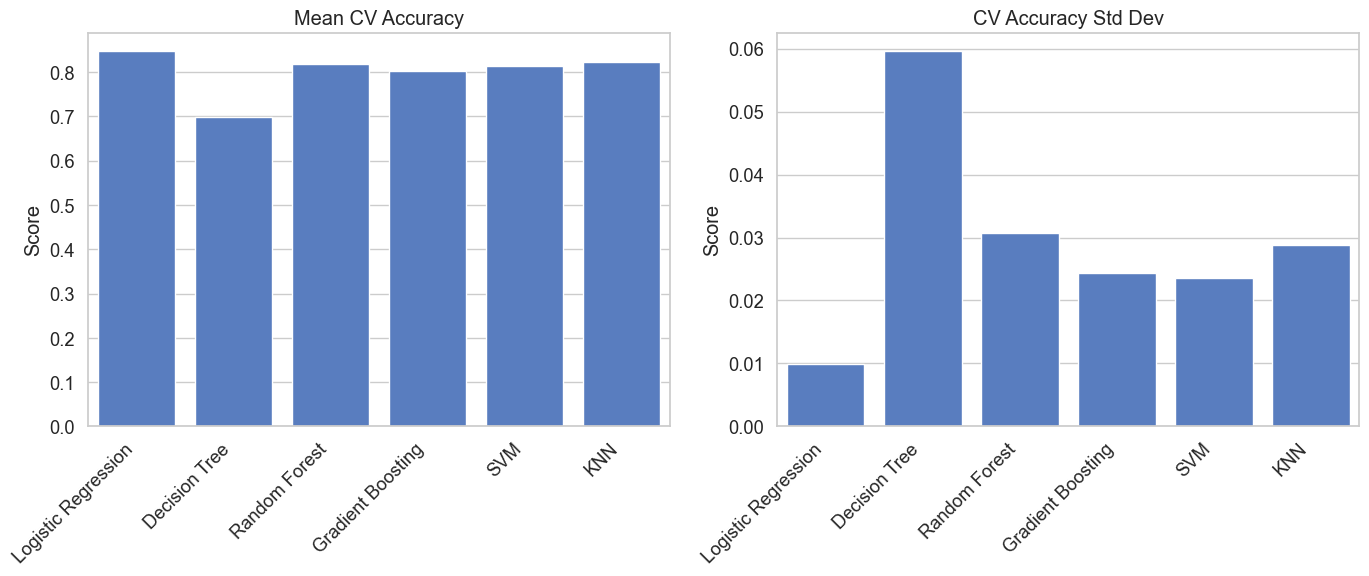

In [63]:
# Visualize CV results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
model_names = list(cv_results.keys())

for ax, metric, title in zip(axes, ['mean', 'std'], ['Mean CV Accuracy', 'CV Accuracy Std Dev']):
    values = [cv_results[name].mean() if metric == 'mean' else cv_results[name].std() for name in model_names]
    sns.barplot(x=model_names, y=values, ax=ax)
    ax.set_title(title)
    ax.set_xticklabels(model_names, rotation=45, ha='right')
    ax.set_ylabel('Score')
plt.tight_layout()

# Hyperparameter tuning

In [68]:
lr_pipeline = baseline_model['Logistic Regression']

lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'liblinear']
}

lr_grid = GridSearchCV(estimator=lr_pipeline, 
                       param_grid=lr_param_grid, 
                       cv=cv_strategy, 
                       scoring='accuracy', 
                       n_jobs=-1, 
                       verbose=1)
lr_grid.fit(X_train, y_train)
print(f"Best parameters for Logistic Regression: {lr_grid.best_params_}")
print(f"Best CV accuracy for Logistic Regression: {lr_grid.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for Logistic Regression: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV accuracy for Logistic Regression: 0.8554


In [69]:
rf_pipeline = baseline_model['Random Forest']

rf_param_grid = {
    'classifier__n_estimators': np.random.randint(100, 5000, size=5),
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(estimator=rf_pipeline,
                          param_grid=rf_param_grid,
                          cv=cv_strategy,
                          scoring='accuracy',
                          n_jobs=-1,
                          verbose=1)
rf_grid.fit(X_train, y_train)
print(f"Best parameters for Random Forest: {rf_grid.best_params_}")
print(f"Best CV accuracy for Random Forest: {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best parameters for Random Forest: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': np.int64(1441)}
Best CV accuracy for Random Forest: 0.8263


In [72]:
rf_pipeline = baseline_model['Random Forest']

rf_param_grid = {
    'classifier__n_estimators': np.random.randint(100, 5000, size=5),
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

rf_grid = RandomizedSearchCV(estimator=rf_pipeline,
                             param_distributions=rf_param_grid,
                             cv=cv_strategy,
                             scoring='accuracy',
                             n_iter=20,
                             n_jobs=-1,
                             verbose=1)
rf_grid.fit(X_train, y_train)
print(f"Best parameters for Random Forest: {rf_grid.best_params_}")
print(f"Best CV accuracy for Random Forest: {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for Random Forest: {'classifier__n_estimators': np.int64(1391), 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': 30}
Best CV accuracy for Random Forest: 0.8263


In [74]:
best_models = {
    'Logistic Regression': lr_grid.best_estimator_,
    'Random Forest': rf_grid.best_estimator_
}

print("Best models stored in dictionary for future evaluation.")
print(f'Best Logistic Regression accuracy: {lr_grid.best_score_:.4f}')
print(f'Best Random Forest accuracy: {rf_grid.best_score_:.4f}')

champion_model = max(
    [("LogisticRegression", lr_grid.best_score_), ("RandomForest", rf_grid.best_score_)],
    key=lambda x: x[1]
)[0]
print(f"Champion model based on CV accuracy: {champion_model}")

Best models stored in dictionary for future evaluation.
Best Logistic Regression accuracy: 0.8554
Best Random Forest accuracy: 0.8263
Champion model based on CV accuracy: LogisticRegression


In [75]:
print(
    f"{"Model":<35} {"Accuracy":<20} {"Precision":<20} {"Recall":<20} {"F1-Score":<20}"
)

test_results = {}
for name, model in best_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    test_results[name] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    }
    
    print(f"{name:<35} {acc:<20.4f} {prec:<20.4f} {rec:<20.4f} {f1:<20.4f}")



Model                               Accuracy             Precision            Recall               F1-Score            
Logistic Regression                 0.8689               0.8333               0.8929               0.8621              
Random Forest                       0.8852               0.8387               0.9286               0.8814              


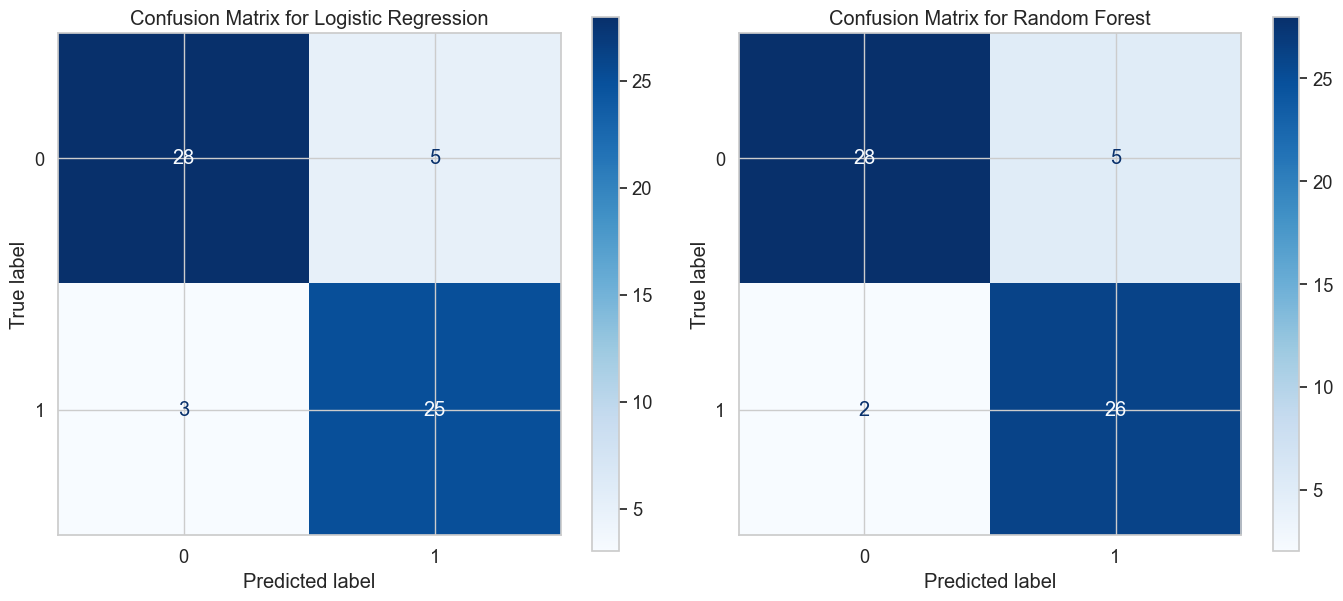

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, model) in zip(axes, best_models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'Confusion Matrix for {name}')
plt.tight_layout()
plt.show()

In [77]:
for name, model in best_models.items():
    print(f"Classification Report for {name}:\n")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    print("-" * 60)

Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

------------------------------------------------------------
Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61

------------------------------------------------------------


In [78]:
# Best features analysis for Random Forest
rf_model = best_models['Random Forest']
feature_importances = rf_model.named_steps['classifier'].feature_importances_
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values(by='importance', ascending=False)

In [82]:
feature_importance_df.values[:10]

array([['cat__thal_3.0', 0.11255846917152919],
       ['cat__ca_0.0', 0.0927732051443049],
       ['cat__thal_7.0', 0.0888028169148588],
       ['cat__cp_4.0', 0.08647661755760501],
       ['num__thalach', 0.08606405648203555],
       ['num__oldpeak', 0.07327415772842759],
       ['num__age', 0.062091391843407076],
       ['num__chol', 0.05604737046321491],
       ['num__trestbps', 0.04953870256422589],
       ['cat__exang_1.0', 0.04013803456240726]], dtype=object)

In [87]:
champion_model

'LogisticRegression'

In [ ]:
# inference on test set
champion_model = lr_grid
champion_model.fit(X_train, y_train)


y_test_pred = champion_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_acc

Fitting 5 folds for each of 10 candidates, totalling 50 fits


0.8688524590163934

In [92]:
import pickle
with open('heart_disease_model.pkl', 'wb') as f:
    pickle.dump(champion_model, f)

In [93]:
model = pickle.load(open('heart_disease_model.pkl', 'rb'))

In [94]:
model.predict(X_test)

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1])

In [96]:
new_patient = pd.DataFrame([{
    'age': 55,
    'trestbps': 140,
    'chol': 250,
    'thalach': 140,
    'oldpeak': 2.0,
    'sex': 1,
    'cp': 4,
    'fbs': 0,
    'restecg': 0,
    'exang': 1,
    'slope': 2,
    'ca': 1,
    'thal': 7
}])

In [101]:
if model.predict(new_patient)[0] == 1:
    print("The model predicts that the patient has heart disease.")
else:
    print("The model predicts that the patient does not have heart disease.")

The model predicts that the patient has heart disease.
